<a href="https://colab.research.google.com/github/Ryo-pro-edt/100PONNOCK/blob/main/cifar10SOTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#softplus -> sigmoid　Mish＋SwishよりもSwish*Swishのほうが精度がよくなる
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 再現性を確保するために乱数シードを設定
def set_seed(seed=1):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
set_seed()

# デバイス設定（GPUが利用可能ならGPUを使用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Mish活性化関数
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.sigmoid(x))#sigmoid

# Swish活性化関数
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

# MixUp データ拡張関数
def mixup(x, y, alpha=0.2):
    #Mixupデータ拡張を適用する関数
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]

    # ラベルもミックス
    mixed_y = lam * y + (1 - lam) * y[index]

    return mixed_x, mixed_y

# Squeeze-and-Excitation ブロック
class SqueezeExciteBlock(nn.Module):
    def __init__(self, in_channels, ratio=16):
        super(SqueezeExciteBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // ratio, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // ratio, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size, channels, _, _ = x.size()
        y = self.avg_pool(x).view(batch_size, channels)
        y = self.fc(y).view(batch_size, channels, 1, 1)
        return x * y.expand_as(x)

# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, activation=Mish()):
        super(ResidualBlock, self).__init__()
        self.activation = activation

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.activation(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.activation(out)
        return out

# モデルアーキテクチャの定義
class CIFAR10Model(nn.Module):
    def __init__(self, num_classes=10):
        super(CIFAR10Model, self).__init__()

        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            Mish()
        )

        self.block1 = nn.Sequential(
            ResidualBlock(64, 64, activation=Mish()),
            ResidualBlock(64, 64, activation=Mish()),
            SqueezeExciteBlock(64),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2)
        )

        self.block2 = nn.Sequential(
            ResidualBlock(64, 128, activation=Swish()),
            ResidualBlock(128, 128, activation=Swish()),
            SqueezeExciteBlock(128),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3)
        )

        self.block3 = nn.Sequential(
            ResidualBlock(128, 256, activation=nn.LeakyReLU()),
            ResidualBlock(256, 256, activation=nn.LeakyReLU()),
            SqueezeExciteBlock(256),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.4)
        )

        self.block4 = nn.Sequential(
            ResidualBlock(256, 512, activation=nn.ReLU()),
            ResidualBlock(512, 512, activation=nn.ReLU()),
            SqueezeExciteBlock(512),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            Mish(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            Mish(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.init_conv(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

# CIFAR-10データセットをロード
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

# CIFAR-10のクラスラベル
cifar10_labels = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# モデル、損失関数、オプティマイザの初期化
model = CIFAR10Model(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.RAdam(model.parameters(), lr=0.001, weight_decay=1e-6)

# 学習率スケジューラとアーリーストッピングの設定
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
best_val_accuracy = 0
patience = 15
epochs_without_improvement = 0

print("Model Architecture:")
print(model)

# 訓練ループ
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs=200):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []
    lr_history = []
    best_val_acc = 0.0

    print("\nStarting training with advanced techniques...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # MixUpを適用
            inputs_mix, labels_mix = mixup(inputs, F.one_hot(labels, 10).float())

            optimizer.zero_grad()

            outputs = model(inputs_mix)
            loss = criterion(outputs, labels_mix)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            # MixUpのため、直接的な精度計算は複雑になるためスキップ

        # 検証
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = correct_val / total_val
        val_loss = running_val_loss / len(test_dataset)

        train_loss_history.append(epoch_loss)
        train_acc_history.append(0) # Mixupのため訓練精度はダミー
        val_loss_history.append(val_loss)
        val_acc_history.append(epoch_acc)
        lr_history.append(optimizer.param_groups[0]['lr'])

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {epoch_acc:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

        scheduler.step()

        # アーリーストッピング
        global best_val_accuracy, epochs_without_improvement
        if epoch_acc > best_val_accuracy:
            best_val_accuracy = epoch_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(torch.load('best_model.pth'))
                break

    return {
        'loss': train_loss_history,
        'val_loss': val_loss_history,
        'accuracy': train_acc_history,
        'val_accuracy': val_acc_history,
        'lr': lr_history
    }

history = train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs=200)

# 最終的なテスト精度を計算
model.eval()
all_test_preds = []
all_test_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

final_test_accuracy = np.mean(np.array(all_test_preds) == np.array(all_test_labels))
print(f"\nFinal Test Accuracy: {final_test_accuracy:.4f}")

# --- 混同行列の可視化（テストデータ） ---
test_cm = confusion_matrix(all_test_labels, all_test_preds)
disp_test = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=cifar10_labels)
print("Test Confusion Matrix:")
plt.figure(figsize=(10, 8))
disp_test.plot(xticks_rotation=45, cmap='Oranges')
plt.title("Test Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

# --- 詳細な学習履歴の可視化 ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 精度の推移
axes[0, 0].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Training & Validation Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 損失の推移
axes[0, 1].plot(history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Training & Validation Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 学習率の推移
axes[1, 0].plot(history['lr'], linewidth=2, color='red')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].grid(True, alpha=0.3)

# 精度の詳細表示
epochs_range = range(len(history['val_accuracy']))
axes[1, 1].plot(epochs_range, history['val_accuracy'], 'r-', linewidth=2, label='Validation')
axes[1, 1].fill_between(epochs_range, history['val_accuracy'], alpha=0.1, color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Detailed Accuracy Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# クラス別精度の分析
print("\nDetailed Classification Report:")
print(classification_report(all_test_labels, all_test_preds,
                            target_names=cifar10_labels, digits=4))



Using device: cuda
Model Architecture:
CIFAR10Model(
  (init_conv): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Mish()
  )
  (block1): Sequential(
    (0): ResidualBlock(
      (activation): Mish()
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (activation): Mish()
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

KeyboardInterrupt: 

Device: cuda
Epoch 1 | Val Acc 0.3650 | LR 0.005352
Epoch 2 | Val Acc 0.4899 | LR 0.005350
Epoch 3 | Val Acc 0.5677 | LR 0.005346
Epoch 4 | Val Acc 0.6478 | LR 0.005340
Epoch 5 | Val Acc 0.6807 | LR 0.005331
Epoch 6 | Val Acc 0.7266 | LR 0.005319
Epoch 7 | Val Acc 0.7519 | LR 0.005304
Epoch 8 | Val Acc 0.7867 | LR 0.005287
Epoch 9 | Val Acc 0.7996 | LR 0.005268
Epoch 10 | Val Acc 0.8106 | LR 0.005245
Epoch 11 | Val Acc 0.8179 | LR 0.005221
Epoch 12 | Val Acc 0.8255 | LR 0.005193
Epoch 13 | Val Acc 0.8473 | LR 0.005164
Epoch 14 | Val Acc 0.8479 | LR 0.005132
Epoch 15 | Val Acc 0.8516 | LR 0.005097
Epoch 16 | Val Acc 0.8551 | LR 0.005060
Epoch 17 | Val Acc 0.8653 | LR 0.005021
Epoch 18 | Val Acc 0.8780 | LR 0.004979
Epoch 19 | Val Acc 0.8757 | LR 0.004935
Epoch 20 | Val Acc 0.8795 | LR 0.004889
Epoch 21 | Val Acc 0.8731 | LR 0.004841
Epoch 22 | Val Acc 0.8816 | LR 0.004790
Epoch 23 | Val Acc 0.8975 | LR 0.004738
Epoch 24 | Val Acc 0.8916 | LR 0.004683
Epoch 25 | Val Acc 0.8956 | LR 0.004

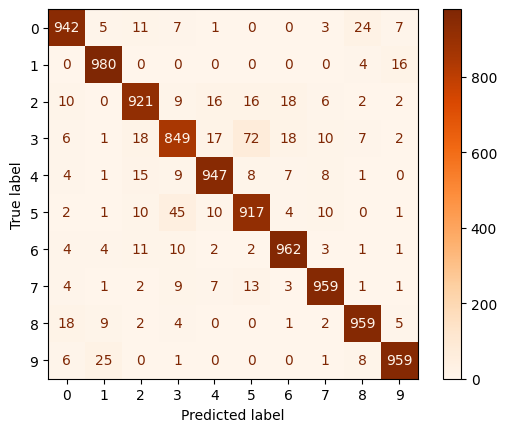

              precision    recall  f1-score   support

           0     0.9458    0.9420    0.9439      1000
           1     0.9542    0.9800    0.9669      1000
           2     0.9303    0.9210    0.9256      1000
           3     0.9003    0.8490    0.8739      1000
           4     0.9470    0.9470    0.9470      1000
           5     0.8920    0.9170    0.9043      1000
           6     0.9497    0.9620    0.9558      1000
           7     0.9571    0.9590    0.9580      1000
           8     0.9523    0.9590    0.9557      1000
           9     0.9648    0.9590    0.9619      1000

    accuracy                         0.9395     10000
   macro avg     0.9394    0.9395    0.9393     10000
weighted avg     0.9394    0.9395    0.9393     10000



In [10]:
# ================================
# CIFAR10 Advanced Training (Colab)
# Retraining with Optuna Optimized Parameters
# ================================

!pip -q install torch torchvision scikit-learn

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# ========= 再現性 =========
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ========= 活性化 =========
class Mish(nn.Module):
    def forward(self,x): return x * torch.tanh(torch.sigmoid(x))

class Swish(nn.Module):
    def forward(self,x): return x * torch.sigmoid(x)

# ========= Mixup =========
def mixup(x,y,alpha=0.2):
    lam=np.random.beta(alpha,alpha)
    idx=torch.randperm(x.size(0)).to(device)
    return lam*x+(1-lam)*x[idx], lam*y+(1-lam)*y[idx]

# ========= SE block =========
class SE(nn.Module):
    def __init__(self,c,r=16):
        super().__init__()
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.fc=nn.Sequential(
            nn.Linear(c,c//r), nn.ReLU(),
            nn.Linear(c//r,c), nn.Sigmoid())
    def forward(self,x):
        b,c,_,_=x.shape
        y=self.pool(x).view(b,c)
        y=self.fc(y).view(b,c,1,1)
        return x*y

# ========= ResBlock =========
class ResBlock(nn.Module):
    def __init__(self,in_c,out_c,stride=1,act=Mish()):
        super().__init__()
        self.act=act
        self.conv1=nn.Conv2d(in_c,out_c,3,stride,1,bias=False)
        self.bn1=nn.BatchNorm2d(out_c)
        self.conv2=nn.Conv2d(out_c,out_c,3,1,1,bias=False)
        self.bn2=nn.BatchNorm2d(out_c)

        self.short=nn.Sequential()
        if stride!=1 or in_c!=out_c:
            self.short=nn.Sequential(
                nn.Conv2d(in_c,out_c,1,stride,bias=False),
                nn.BatchNorm2d(out_c))

    def forward(self,x):
        out=self.act(self.bn1(self.conv1(x)))
        out=self.bn2(self.conv2(out))
        out+=self.short(x)
        return self.act(out)

# ========= Model =========
class CIFAR10Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.init=nn.Sequential(
            nn.Conv2d(3,64,3,1,1,bias=False),
            nn.BatchNorm2d(64), Mish())

        self.block1=nn.Sequential(
            ResBlock(64,64,act=Mish()), ResBlock(64,64,act=Mish()),
            SE(64), nn.MaxPool2d(2), nn.Dropout2d(0.2))

        self.block2=nn.Sequential(
            ResBlock(64,128,act=Swish()), ResBlock(128,128,act=Swish()),
            SE(128), nn.MaxPool2d(2), nn.Dropout2d(0.3))

        self.block3=nn.Sequential(
            ResBlock(128,256,act=nn.LeakyReLU()),
            ResBlock(256,256,act=nn.LeakyReLU()),
            SE(256), nn.MaxPool2d(2), nn.Dropout2d(0.4))

        self.block4=nn.Sequential(
            ResBlock(256,512,act=nn.ReLU()),
            ResBlock(512,512,act=nn.ReLU()),
            SE(512))

        self.fc=nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512,256), nn.BatchNorm1d(256), Mish(),
            nn.Dropout(0.5),
            nn.Linear(256,128), nn.BatchNorm1d(128), Mish(),
            nn.Dropout(0.3),
            nn.Linear(128,10))

    def forward(self,x):
        x=self.init(x)
        x=self.block1(x)
        x=self.block2(x)
        x=self.block3(x)
        x=self.block4(x)
        return self.fc(x)

# ========= Dataset =========
transform_train=transforms.Compose([
    transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])
transform_test=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])

trainset=datasets.CIFAR10(root='./data',train=True,download=True,transform=transform_train)
testset=datasets.CIFAR10(root='./data',train=False,download=True,transform=transform_test)

train_loader=DataLoader(trainset,batch_size=64,shuffle=True,num_workers=2,pin_memory=True)
test_loader=DataLoader(testset,batch_size=256,shuffle=False,num_workers=2,pin_memory=True)

# ========= Train with Optimized Params =========
model=CIFAR10Model().to(device)
criterion=nn.CrossEntropyLoss()
# Using parameters from Optuna Best Trial (Trial 1)
optimizer=optim.AdamW(model.parameters(), lr=0.005351652509574305, weight_decay=0.00023666411455980116)
scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

def train(num_epochs=200,patience=15):
    best_val=0
    wait=0
    hist={"val_acc":[],"val_loss":[]}

    for epoch in range(num_epochs):
        model.train()
        for x,y in train_loader:
            x,y=x.to(device),y.to(device)
            x,y=mixup(x,F.one_hot(y,10).float())
            optimizer.zero_grad()
            loss=criterion(model(x),y)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        correct=0; loss_sum=0
        with torch.no_grad():
            for x,y in test_loader:
                x,y=x.to(device),y.to(device)
                out=model(x)
                loss_sum+=criterion(out,y).item()*x.size(0)
                correct+=(out.argmax(1)==y).sum().item()

        val_acc=correct/len(testset)
        val_loss=loss_sum/len(testset)
        hist["val_acc"].append(val_acc)
        hist["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1} | Val Acc {val_acc:.4f} | LR {optimizer.param_groups[0]['lr']:.6f}")

        scheduler.step()

        if val_acc>best_val:
            best_val=val_acc
            wait=0
            torch.save(model.state_dict(),"best_optimized.pth")
        else:
            wait+=1
            if wait>=patience:
                print("Early stopping")
                break

    model.load_state_dict(torch.load("best_optimized.pth"))
    print("Best Val Accuracy:",best_val)
    return hist,best_val

history,best_val=train()

# ========= Final Test (BEST MODEL) =========
model.eval()
preds=[]; labels=[]
with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device)
        p=model(x).argmax(1).cpu().numpy()
        preds.extend(p); labels.extend(y.numpy())

final_acc=np.mean(np.array(preds)==np.array(labels))
print("\nFinal Test Accuracy (Best Model):",final_acc)

# ========= Confusion Matrix =========
cm=confusion_matrix(labels,preds)
ConfusionMatrixDisplay(cm).plot(cmap="Oranges")
plt.show()

print(classification_report(labels,preds,digits=4))

In [4]:
import numpy as np

# 混同行列が `cm` という変数に格納されていると仮定
# クラスラベルが `cifar10_labels` という変数に格納されていると仮定

# 誤分類が多いクラスのペアを特定
misclassification_pairs = []
num_classes = cm.shape[0]

for i in range(num_classes):
    for j in range(num_classes):
        if i != j:  # 対角要素（正しく分類されたケース）は除外
            # (i, j)はクラスiがクラスjと誤分類された数
            # (j, i)はクラスjがクラスiと誤分類された数
            misclassification_pairs.append({
                'true_class': cifar10_labels[i],
                'predicted_class': cifar10_labels[j],
                'count': int(cm[i, j])
            })

# 誤分類の数で降順にソート
misclassification_pairs.sort(key=lambda x: x['count'], reverse=True)

print("Top 10 misclassified class pairs:")
for pair in misclassification_pairs[:10]:
    print(f"  True: {pair['true_class']:<10} -> Predicted: {pair['predicted_class']:<10} (Count: {pair['count']})")

Top 10 misclassified class pairs:
  True: cat        -> Predicted: dog        (Count: 80)
  True: dog        -> Predicted: cat        (Count: 45)
  True: truck      -> Predicted: automobile (Count: 21)
  True: ship       -> Predicted: airplane   (Count: 19)
  True: automobile -> Predicted: truck      (Count: 17)
  True: bird       -> Predicted: deer       (Count: 17)
  True: airplane   -> Predicted: ship       (Count: 16)
  True: cat        -> Predicted: bird       (Count: 15)
  True: bird       -> Predicted: frog       (Count: 14)
  True: cat        -> Predicted: frog       (Count: 14)


Number of 'cat' misclassified as 'dog': 80
Number of 'dog' misclassified as 'cat': 45


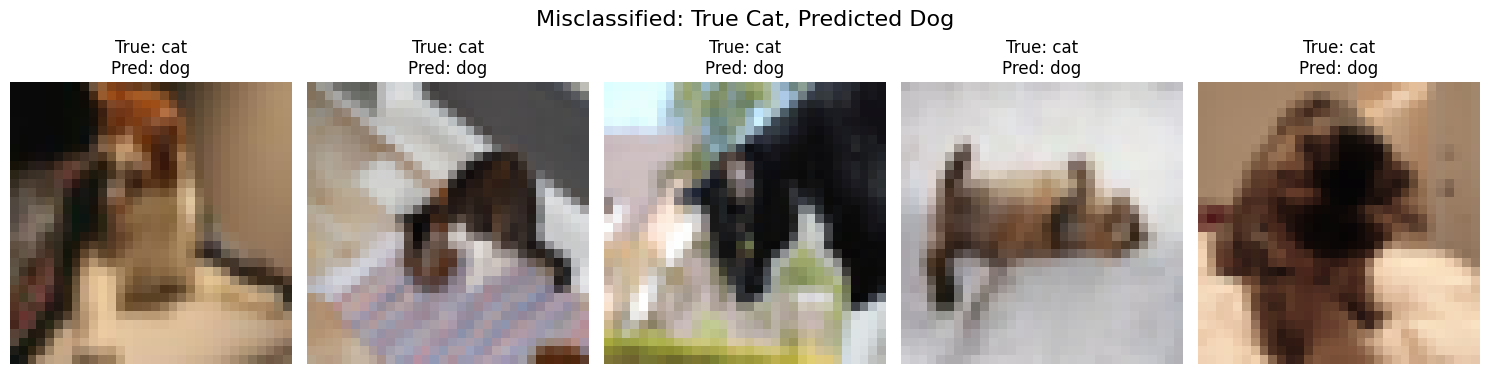

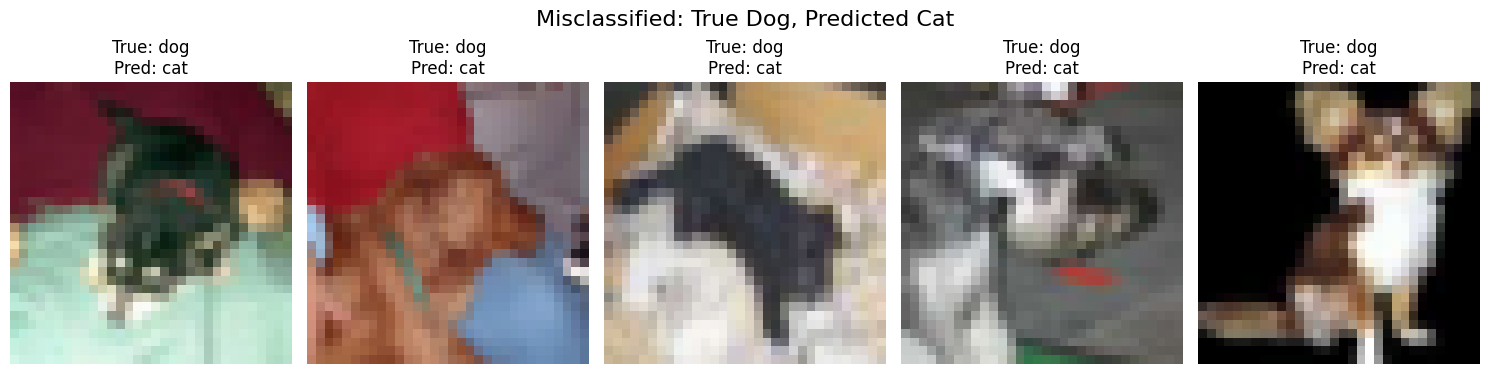

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get numerical labels for 'cat' and 'dog'
cat_label_idx = cifar10_labels.index('cat')  # Should be 3
dog_label_idx = cifar10_labels.index('dog')  # Should be 5

# Convert lists to numpy arrays for easier indexing
labels_np = np.array(labels)
preds_np = np.array(preds)

# Identify indices where true is 'cat' but predicted is 'dog'
misclassified_cat_as_dog_indices = np.where((labels_np == cat_label_idx) & (preds_np == dog_label_idx))[0]

# Identify indices where true is 'dog' but predicted is 'cat'
misclassified_dog_as_cat_indices = np.where((labels_np == dog_label_idx) & (preds_np == cat_label_idx))[0]

print(f"Number of 'cat' misclassified as 'dog': {len(misclassified_cat_as_dog_indices)}")
print(f"Number of 'dog' misclassified as 'cat': {len(misclassified_dog_as_cat_indices)}")

# Function to display images
def display_misclassified_images(indices, title, num_images=5):
    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16)
    display_count = 0
    for i, idx in enumerate(indices):
        if display_count >= num_images:
            break

        # Get original image and transform back for display (denormalize)
        # Note: test_dataset items are (image, label)
        img_tensor, true_label_idx = testset[idx] # testset is the raw dataset, not the loader

        # Denormalize the image for display
        # Mean and std from transform_test: ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy() # Convert from C, H, W to H, W, C
        img_np = std * img_np + mean # Denormalize
        img_np = np.clip(img_np, 0, 1) # Clip values to [0, 1]

        predicted_label_idx = preds_np[idx]

        plt.subplot(1, num_images, display_count + 1)
        plt.imshow(img_np)
        plt.title(f"True: {cifar10_labels[true_label_idx]}\nPred: {cifar10_labels[predicted_label_idx]}")
        plt.axis('off')
        display_count += 1
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

# Display some misclassified 'cat' images as 'dog'
display_misclassified_images(misclassified_cat_as_dog_indices, "Misclassified: True Cat, Predicted Dog", num_images=5)

# Display some misclassified 'dog' images as 'cat'
display_misclassified_images(misclassified_dog_as_cat_indices, "Misclassified: True Dog, Predicted Cat", num_images=5)

In [6]:
!pip install -q optuna

In [7]:
import optuna

def objective(trial):
    # 探索するハイパーパラメータの定義
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["RAdam", "AdamW"])

    # モデルの初期化 (既存の定義を利用)
    model = CIFAR10Model().to(device)

    if optimizer_name == "RAdam":
        optimizer = optim.RAdam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    # 最適化のための軽量な訓練ループ (10-20エポック程度)
    num_epochs = 20
    best_val_acc = 0

    for epoch in range(num_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            x_mix, y_mix = mixup(x, F.one_hot(y, 10).float())
            optimizer.zero_grad()
            loss = criterion(model(x_mix), y_mix)
            loss.backward()
            optimizer.step()

        # バリデーション
        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                correct += (out.argmax(1) == y).sum().item()

        val_acc = correct / len(testset)
        best_val_acc = max(best_val_acc, val_acc)

        # 中間結果の報告とPruning（枝刈り）
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        scheduler.step()

    return best_val_acc

In [8]:
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10) # 試行回数はリソースに合わせて調整してください

print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-03-30 16:27:55,790] A new study created in memory with name: no-name-03bd91fe-7cf8-48e5-b0ab-7108c3fc3c90
[I 2026-03-30 16:34:19,808] Trial 0 finished with value: 0.7595 and parameters: {'lr': 0.0033412985674737806, 'weight_decay': 0.0003696096194496965, 'optimizer': 'RAdam'}. Best is trial 0 with value: 0.7595.
[I 2026-03-30 16:40:29,656] Trial 1 finished with value: 0.8881 and parameters: {'lr': 0.005351652509574305, 'weight_decay': 0.00023666411455980116, 'optimizer': 'AdamW'}. Best is trial 1 with value: 0.8881.
[I 2026-03-30 16:46:56,055] Trial 2 finished with value: 0.8742 and parameters: {'lr': 0.0001172623247650951, 'weight_decay': 5.149252065065435e-06, 'optimizer': 'AdamW'}. Best is trial 1 with value: 0.8881.
[I 2026-03-30 16:53:39,087] Trial 3 finished with value: 0.8745 and parameters: {'lr': 0.0001052041590334568, 'weight_decay': 6.812667784497436e-05, 'optimizer': 'AdamW'}. Best is trial 1 with value: 0.8881.
[I 2026-03-30 17:00:02,923] Trial 4 finished with valu

Best trial:
  Value: 0.8881
  Params: 
    lr: 0.005351652509574305
    weight_decay: 0.00023666411455980116
    optimizer: AdamW


In [9]:
try:
    display(optuna.visualization.plot_optimization_history(study))
    display(optuna.visualization.plot_param_importances(study))
except:
    print("Visualization requires plotly installed.")

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import math
import numpy as np

device="cuda" if torch.cuda.is_available() else "cpu"

# =========================
# RandAugment + 基本Aug
# =========================
train_tf = T.Compose([
    T.RandomCrop(32,padding=4),
    T.RandomHorizontalFlip(),
    T.RandAugment(num_ops=2, magnitude=9),
    T.ToTensor(),
    T.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010)),
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root="./data",train=True,download=True,transform=train_tf)
testset  = torchvision.datasets.CIFAR10(root="./data",train=False,download=True,transform=test_tf)

trainloader = DataLoader(trainset,batch_size=128,shuffle=True,num_workers=2)
testloader  = DataLoader(testset,batch_size=256,shuffle=False,num_workers=2)

# =========================
# CutMix
# =========================
def cutmix(x,y,alpha=1.0):
    lam=np.random.beta(alpha,alpha)
    rand_index=torch.randperm(x.size()[0]).to(device)
    y_a,y_b=y,y[rand_index]

    bbx1,bby1,bbx2,bby2 = rand_bbox(x.size(), lam)
    x[:,:,bbx1:bbx2,bby1:bby2]=x[rand_index,:,bbx1:bbx2,bby1:bby2]
    lam=1-((bbx2-bbx1)*(bby2-bby1)/(x.size()[-1]*x.size()[-2]))
    return x,y_a,y_b,lam

def rand_bbox(size, lam):
    W=size[2]; H=size[3]
    cut_rat=np.sqrt(1.-lam)
    cut_w=int(W*cut_rat); cut_h=int(H*cut_rat)
    cx=np.random.randint(W); cy=np.random.randint(H)
    bbx1=np.clip(cx-cut_w//2,0,W)
    bby1=np.clip(cy-cut_h//2,0,H)
    bbx2=np.clip(cx+cut_w//2,0,W)
    bby2=np.clip(cy+cut_h//2,0,H)
    return bbx1,bby1,bbx2,bby2

# =========================
# WideResNet
# =========================
class BasicBlock(nn.Module):
    def __init__(self,in_c,out_c,stride=1):
        super().__init__()
        self.bn1=nn.BatchNorm2d(in_c)
        self.conv1=nn.Conv2d(in_c,out_c,3,stride,1,bias=False)
        self.bn2=nn.BatchNorm2d(out_c)
        self.conv2=nn.Conv2d(out_c,out_c,3,1,1,bias=False)
        self.shortcut=nn.Sequential()
        if stride!=1 or in_c!=out_c:
            self.shortcut=nn.Conv2d(in_c,out_c,1,stride,bias=False)
    def forward(self,x):
        out=self.conv1(torch.relu(self.bn1(x)))
        out=self.conv2(torch.relu(self.bn2(out)))
        return out+self.shortcut(x)

class WideResNet(nn.Module):
    def __init__(self,k=10):
        super().__init__()
        n=4
        widths=[16,16*k,32*k,64*k]
        self.conv=nn.Conv2d(3,widths[0],3,1,1)
        self.layer1=self._make(widths[0],widths[1],n,1)
        self.layer2=self._make(widths[1],widths[2],n,2)
        self.layer3=self._make(widths[2],widths[3],n,2)
        self.bn=nn.BatchNorm2d(widths[3])
        self.fc=nn.Linear(widths[3],10)
    def _make(self,in_c,out_c,n,stride):
        layers=[BasicBlock(in_c,out_c,stride)]
        for _ in range(n-1): layers.append(BasicBlock(out_c,out_c))
        return nn.Sequential(*layers)
    def forward(self,x):
        x=self.conv(x)
        x=self.layer1(x)
        x=self.layer2(x)
        x=self.layer3(x)
        x=torch.relu(self.bn(x))
        x=torch.nn.functional.avg_pool2d(x,8)
        x=x.view(x.size(0),-1)
        return self.fc(x)

model=WideResNet().to(device)

# =========================
# Label smoothing
# =========================
criterion=nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer=optim.SGD(model.parameters(),lr=0.1,momentum=0.9,weight_decay=5e-4,nesterov=True)

# Cosine scheduler
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=200)

# EMA
ema_model=WideResNet().to(device)
ema_model.load_state_dict(model.state_dict())
ema_decay=0.999

def update_ema():
    for ema_p,p in zip(ema_model.parameters(),model.parameters()):
        ema_p.data=ema_decay*ema_p.data+(1-ema_decay)*p.data

# =========================
# Training
# =========================
for epoch in range(200):
    model.train()
    for x,y in trainloader:
        x,y=x.to(device),y.to(device)

        x,y_a,y_b,lam=cutmix(x,y)
        pred=model(x)
        loss=lam*criterion(pred,y_a)+(1-lam)*criterion(pred,y_b)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        update_ema()

    scheduler.step()

    # eval
    ema_model.eval()
    correct=0; total=0
    with torch.no_grad():
        for x,y in testloader:
            x,y=x.to(device),y.to(device)
            pred=ema_model(x).argmax(1)
            correct+=(pred==y).sum().item()
            total+=y.size(0)
    print(epoch, correct/total)

0 0.1104
1 0.1028
2 0.1042
3 0.1072
4 0.1331
5 0.1203
6 0.1152
7 0.1074
8 0.1027
9 0.1064


KeyboardInterrupt: 

# test

In [ ]:
# ================================
# CIFAR10 + Optuna objective template
# ================================
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------
# DataLoader（外で定義）
# ----------------
def get_dataloaders(batch_size):

    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform_test)

    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader  = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

    return trainloader, testloader

# ----------------
# シンプルCNN（探索対象）
# ----------------
class SimpleCNN(nn.Module):
    def __init__(self, channels, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(channels, channels*2, 3, padding=1),
            nn.BatchNorm2d(channels*2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear((channels*2)*8*8, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

# ----------------
# 検証精度
# ----------------
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)

    return correct/total

# ================================
# ★ Optuna Objective
# ================================
def objective(trial):

    # ---- 探索空間 ----
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64,128,256])
    channels = trial.suggest_categorical("channels", [32,64,128])
    dropout = trial.suggest_float("dropout", 0.2, 0.6)

    optimizer_name = trial.suggest_categorical("optimizer", ["Adam","SGD"])
    momentum = trial.suggest_float("momentum", 0.8, 0.99)

    # ---- Data ----
    trainloader, testloader = get_dataloaders(batch_size)

    # ---- Model ----
    model = SimpleCNN(channels, dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    # ---- 学習 ----
    EPOCHS = 15
    for epoch in range(EPOCHS):

        model.train()
        for x,y in trainloader:
            x,y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        # ---- 検証 ----
        val_acc = evaluate(model, testloader)

        # ---- Prunerへ報告 ----
        trial.report(val_acc, epoch)

        # ---- 早期打ち切り ----
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_acc

# ================================
# 実行
# ================================
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3)
)

study.optimize(objective, n_trials=20)

print("Best accuracy:", study.best_value)
print("Best params:", study.best_params)